# [Step 5] Uncertainty Quantification: AI 의 자신감 측정과 안전장치

## 0. 서론: 점 추정 (Point Estimation) 의 위험성

### 0.1 "188m 입니다!"라고 확신할 수 있는가?

Step 4 에서 GRU 는 아포지를 `188.01m`라고 예측했음. 오차는 1.5m 에 불과함. 하지만, 만약 실제 비행에서 갑작스러운 돌풍이 불거나 센서 하나가 완전히 고장 난다면? AI 가 본 적 없는 낯선 데이터를 만났을 때 엉뚱한 값을 내뱉으면서 **"100% 확신합니다"** 라고 주장한다면, 낙하산은 엉뚱한 타이밍에 펴질 것이고 미션은 실패하게 됨.

**Kendall & Gal (2017) 의 경고:**

> "In two recent examples this has had disastrous consequences. In May 2016 there was the first fatality from an assisted driving system, caused by the perception system confusing the white side of a trailer for bright sky. If both these algorithms were able to assign a high level of uncertainty to their erroneous predictions, then the system may have been able to make better decisions and likely avoid disaster."
> — *What Uncertainties Do We Need in Bayesian Deep Learning for Computer Vision?*, NIPS 2017

**교훈:** 정확도 (Accuracy) 만 높은 AI 는 위험하다. **불확실성 (Uncertainty) 을 정량화할 수 있는 AI**가 안전하다.

### 0.2 엔지니어링 관점의 UQ (Uncertainty Quantification)

기계설계에서 **안전율 (Safety Factor)** 을 두듯이, AI 예측에도 **오차 범위 (Error Bar)** 가 필요함.

| 항목 | 기존 (점 추정) | UQ 적용 (구간 추정) |
|------|---------------|-------------------|
| **예측식** | $y = f(x)$ | $y = f(x) \pm \sigma$ |
| **신뢰도** | 알 수 없음 | 95% 신뢰구간 등 |
| **안전장치** | 임계값 고정 | **불확실성 기반 동적 임계값** |
| **OOD 감지** | 불가능 | **불확실성 급증으로 감지** |

**Gal & Ghahramani (2016) 의 통찰:**

> "Model uncertainty is indispensable for the deep learning practitioner as well. With model confidence at hand we can treat uncertain inputs and special cases explicitly. For example, in the case of classification, a model might return a result with high uncertainty. In this case we might decide to pass the input to a human for classification... or in a nuclear power plant with a system responsible for critical infrastructure."
> — *Dropout as a Bayesian Approximation*, ICML 2016

우리는 AI 에게 **"모르면 모른다고 (불확실성이 높다고) 말해라"** 라고 가르쳐야 함. 이것이 온보드 알고리즘의 안전성을 담보하는 핵심임.

## 1. 이론적 배경: Dropout 을 이용한 베이지안 근사

### 1.1 Aleatoric vs Epistemic Uncertainty (수식적 정의)

불확실성에는 두 가지 종류가 있음 (Kendall & Gal, 2017).

#### (1) Aleatoric Uncertainty (데이터 불확실성)

**정의:** 관측에 내재된 노이즈. 데이터가 아무리 많아도 줄일 수 없음.

$$ \text{Aleatoric: } \sigma^2_{\text{aleatoric}}(x) = \text{Var}(y | x, W^*) $$

**예시:**
- 센서 노이즈 (가속도계 ±0.5m/s²)
- 대기 난류 (돌풍 ±3m/s)
- **로켓 비행:** 연소실 압력 변동, 핀 제작 공차

**특징:**
> "Aleatoric uncertainty captures noise inherent in the observations. This could be for example sensor noise or motion noise, resulting in uncertainty which cannot be reduced even if more data were to be collected."
> — Kendall & Gal (2017), Section 1

#### (2) Epistemic Uncertainty (모델 불확실성)

**정의:** 모델 파라미터의 무지. 학습 데이터가 부족해서 생김. **데이터를 더 모으면 줄어듦.**

$$ \text{Epistemic: } \sigma^2_{\text{epistemic}}(x) = \text{Var}_{W \sim p(W|D)}[f_W(x)] $$

**예시:**
- 학습 데이터에 없는 비행 조건 (초고속, 초저기압)
- 센서 고장 (본 적 없는 패턴)
- **로켓 비행:** 질량 2 배 로켓, 돌풍 30m/s (OOD 상황)

**특징:**
> "Epistemic uncertainty accounts for uncertainty in the model parameters – uncertainty which can be explained away given enough data. This is particularly important for safety-critical systems, where epistemic uncertainty is required to detect situations which have never been seen by the model before."
> — Kendall & Gal (2017), Section 5.2

#### (3) 총 예측 분산 (Total Predictive Variance)

**두 불확실성의 합:**

$$ \text{Var}(y^*) = \underbrace{\sigma^2_{\text{aleatoric}}}_{\text{데이터 노이즈}} + \underbrace{\sigma^2_{\text{epistemic}}}_{\text{모델 무지}} $$

**Kendall & Gal (2017) 의 결합 수식 (회귀Task):**

$$ \text{Var}(y) \approx \underbrace{\frac{1}{T} \sum_{t=1}^{T} \hat{y}_t^2 - \left(\frac{1}{T} \sum_{t=1}^{T} \hat{y}_t\right)^2}_{\text{Epistemic (MC Dropout)}} + \underbrace{\frac{1}{T} \sum_{t=1}^{T} \hat{\sigma}_t^2}_{\text{Aleatoric (Learned)}} $$

### 1.2 Monte Carlo Dropout (MC Dropout) 의 수학적 근거

**Gal & Ghahramani (2016) 의 핵심 발견:**

> "We show that a neural network with arbitrary depth and non-linearities, with dropout applied before every weight layer, is mathematically equivalent to an approximation to the probabilistic deep Gaussian process."
> — Gal & Ghahramani (2016), Section 3

**기존 Dropout 의 한계:**
- 학습 시: 랜덤 뉴런 제거 (Overfitting 방지)
- **추론 시**: 모든 뉴런 사용, 가중치 스케일링 (**불확실성 정보 폐기**)

**MC Dropout 의 혁신:**
- **추론 시에도 Dropout 을 켬** (T 번 확률적 순전파)
- 기존 모델을 **재학습 없이** 베이지안 모델로 변환

#### (1) 예측 평균 (Predictive Mean)

$$ \mathbb{E}[y^* | x^*] \approx \frac{1}{T} \sum_{t=1}^{T} \hat{y}^*(x^*, \hat{W}_t) $$

여기서 $\hat{W}_t \sim q(W)$ 는 Dropout 으로 샘플링된 t 번째 모델 파라미터.

#### (2) 예측 분산 (Predictive Variance)

**Gal & Ghahramani (2016), Proposition D:**

$$ \text{Var}(y^* | x^*) \approx \tau^{-1} I_D + \frac{1}{T} \sum_{t=1}^{T} \hat{y}^*(x^*, \hat{W}_t)^T \hat{y}^*(x^*, \hat{W}_t) - \mathbb{E}[y^*]^T \mathbb{E}[y^*] $$

**실무적 근사 (τ^-1 항 무시):**

$$ \text{Var}(y^*) \approx \underbrace{\frac{1}{T} \sum_{t=1}^{T} \hat{y}_t^2 - \left(\frac{1}{T} \sum_{t=1}^{T} \hat{y}_t\right)^2}_{\text{표본 분산 (Sample Variance)}} $$

**해석:**
- T 번 추론한 값들의 **분산**이 곧 **모델 불확실성 (Epistemic)**
- 분산이 큼 → 모델이 헷갈려함 → **위험 상황**

#### (3) 왜 Dropout 인가? (우월성 증명)

| 방법 | 계산 비용 | 재학습 필요 | OOD 감지 |
|------|----------|-----------|----------|
| **Ensemble** | T 배 (T 개 모델) | T 배 | 가능 |
| **Bayesian NN** | 매우 높음 | 필요 | 가능 |
| **MC Dropout** | **T 배 (1 개 모델)** | **불필요** | **가능** |

**Gal & Ghahramani (2016) 의 결론:**

> "This mitigates the problem of representing uncertainty in deep learning without sacrificing either computational complexity or test accuracy. Note that the dropout NN model itself is not changed. To estimate the predictive mean and predictive uncertainty we simply collect the results of stochastic forward passes through the model."
> — Gal & Ghahramani (2016), Section 4

**장점:**
1. **기존 모델 재사용** (Step 4 의 `best_gru_model.pth` 그대로 사용)
2. **상수 실행 시간** (병렬 처리 가능)
3. **수학적으로 엄밀함** (Deep GP 근사 증명됨)

---

### 1.3 OOD (Out-of-Distribution) 감지 능력

**Kendall & Gal (2017) 의 실험 결과:**

| 데이터 종류 | Aleatoric 불확실성 | Epistemic 불확실성 |
|------------|------------------|------------------|
| **학습 데이터와 유사** | 낮음 (일정) | 낮음 |
| **학습 데이터와 다름 (OOD)** | **낮음 (일정)** | **매우 높음 (급증)** |

> "Epistemic uncertainty increases considerably on those test points which lie far from the training sets. This shows that epistemic uncertainty can be explained away with enough data, but is required to capture situations not encountered in the training set."
> — Kendall & Gal (2017), Table 3 & Section 5.2

**로켓 비행 적용:**
- **정상 비행**: Epistemic 낮음 → AI 예측 신뢰
- **비정상 로켓 (OOD)**: Epistemic 급증 → **AI 예측 무시, 안전모드 진입**


In [21]:
# ============================================================================
# [Cell 1] 라이브러리 임포트 및 환경 설정
# ============================================================================
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Step 4 모델 파일 경로
MODEL_PATH = './data/simulated/best_gru_model.pth'
SCALER_PATH = './data/simulated/input_scaler.pkl'
DATA_PATH = './data/simulated/all_trajectories.csv.gz'

Using device: cuda


In [22]:
# ============================================================================
# [Cell 2] Step 4 모델 클래스 재정의
# ============================================================================

class GRUModel(nn.Module):
    """
    Gated Recurrent Unit (GRU) 기반 시계열 모델
    Step 4 에서 정의한 클래스와 완전히 동일해야 함
    """
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, 
                 output_dim=1, dropout=0.2):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # GRU 레이어
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully Connected 출력층
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim),
            nn.Sigmoid()  # energy_ratio 는 0~1 범위
        )
    
    def forward(self, x, hidden=None):
        # GRU 순전파
        gru_out, hidden = self.gru(x, hidden)
        
        # 마지막 타임스텝의 은닉 상태 사용
        last_hidden = gru_out[:, -1, :]
        
        # Fully Connected 층 통과
        output = self.fc(last_hidden)
        
        return output.squeeze(-1), hidden
    
    def init_hidden(self, batch_size):
        """초기 은닉 상태 생성"""
        return torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)


class PhysicsInformedGRU(nn.Module):
    """
    Physics-Informed GRU Wrapper
    Step 4 의 Hard Constraint 구조를 그대로 활용
    """
    def __init__(self, gru_model):
        super().__init__()
        self.gru = gru_model
    
    def forward(self, x, h_curr, v_z):
        """
        Parameters:
            x: 시퀀스 입력 (batch_size, seq_len, input_dim)
            h_curr: 현재 고도 (batch_size,)
            v_z: 현재 수직 속도 (batch_size,)
        
        Returns:
            h_apogee_pred: 예측 아포지 고도
            r_pred: 예측 energy_ratio
        """
        # GRU 로 energy_ratio 예측
        r_pred, _ = self.gru(x)
        
        # 물리 법칙으로 아포지 계산 (Hard Constraint)
        h_theo_gain = (v_z ** 2) / (2 * 9.81)
        h_apogee_pred = h_curr + h_theo_gain * r_pred
        
        return h_apogee_pred, r_pred

In [23]:
# ============================================================================
# [Cell 3] 학습된 모델 및 Scaler 로드
# ============================================================================

# 1. 모델 인스턴스 생성
input_dim = 6  # (altitude, velocity_z, acceleration_z, tilt_angle, gyro_roll, dynamic_pressure)
gru_base = GRUModel(
    input_dim=input_dim, 
    hidden_dim=128, 
    num_layers=2, 
    output_dim=1, 
    dropout=0.2
)
model = PhysicsInformedGRU(gru_base).to(device)

# 2. 가중치 파일 로드
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"Step 4 학습 모델 로드 완료: {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Step 4 모델 파일이 없습니다: {MODEL_PATH}")

# 3. Scaler 로드 (정규화용)
if os.path.exists(SCALER_PATH):
    scaler = joblib.load(SCALER_PATH)
    print(f"Input Scaler 로드 완료: {SCALER_PATH}")
else:
    raise FileNotFoundError(f"Scaler 파일이 없습니다: {SCALER_PATH}")

# 4. 모델 평가 모드로 설정 (기본)
model.eval()

print("\n" + "="*70)
print("Step 5 준비 완료")
print("="*70)
print(f"모델 파라미터: {sum(p.numel() for p in model.parameters()):,} 개")
print(f"입력 차원: {input_dim}")
print(f"드롭아웃 비율: 0.2 (MC Dropout 용)")
print("="*70)

Step 4 학습 모델 로드 완료: ./data/simulated/best_gru_model.pth
Input Scaler 로드 완료: ./data/simulated/input_scaler.pkl

Step 5 준비 완료
모델 파라미터: 159,617 개
입력 차원: 6
드롭아웃 비율: 0.2 (MC Dropout 용)


In [24]:
# ============================================================================
# [Cell 4] MC Dropout 추론 함수 구현 (Gal & Ghahramani, 2016)
# ============================================================================
def predict_with_uncertainty(model, input_tensor, h_curr, v_z, n_samples=100):
    """
    MC Dropout 을 이용한 불확실성 정량화
    
    Parameters:
        model: 학습된 GRU 모델 (Dropout 레이어 포함)
        input_tensor: 입력 시퀀스 (batch, seq_len, features)
        h_curr: 현재 고도 (batch,)
        v_z: 현재 수직 속도 (batch,)
        n_samples: Monte Carlo 샘플링 횟수 (T)
    
    Returns:
        mean: 예측 평균 (batch,)
        std: 예측 표준편차 (batch,) - Epistemic Uncertainty
        predictions: 전체 샘플 (n_samples, batch)
    
    References:
        Gal & Ghahramani (2016), Proposition D - Predictive Variance
    """
    # model.train() 으로 Dropout 활성화
    # (기존 추론은 model.eval() 이지만, MC Dropout 은 train 모드 유지)
    model.train()
    
    predictions = []
    apogee_predictions = []
    
    batch_size = input_tensor.size(0)  # 배치 크기 저장
    
    with torch.no_grad():
        for t in range(n_samples):
            # Dropout 이 매 샘플마다 다른 마스크 적용
            r_pred, _ = model.gru(input_tensor)
            
            # batch dimension 유지
            # (batch, 1) → (batch,) 로만 축소, 차원은 유지
            r_pred = r_pred.view(batch_size)  # 마지막 차원만 제거
            
            # 물리 법칙으로 아포지 계산
            h_theo_gain = (v_z ** 2) / (2 * 9.81)
            h_apogee = h_curr + h_theo_gain * r_pred
            
            # CPU 로 변환 시 차원 명시
            predictions.append(r_pred.cpu().numpy())  # shape: (batch,)
            apogee_predictions.append(h_apogee.cpu().numpy())  # shape: (batch,)
    
    # stack 후 transpose 로 차원 정리
    # list of (batch,) arrays → (n_samples, batch) → (batch, n_samples)
    predictions = np.vstack(predictions).T  # axis=0 로 스태킹 후 전치
    apogee_predictions = np.stack(apogee_predictions, axis=0).T
    
    print(f"   predictions shape: {predictions.shape}")  # 디버깅용: (batch, n_samples)
    
    # Gal & Ghahramani (2016) 수식 구현
    # 예측 평균: E[y*] ≈ 1/T Σ ŷ_t
    mean_r = np.mean(predictions, axis=1)
    mean_apogee = np.mean(apogee_predictions, axis=1)
    
    # 예측 분산: Var[y*] ≈ 1/T Σ ŷ_t² - (1/T Σ ŷ_t)²
    std_r = np.std(predictions, axis=1)
    std_apogee = np.std(apogee_predictions, axis=1)
    
    # 모델 다시 평가 모드로 (다른 용도용)
    model.eval()
    
    return mean_r, std_r, mean_apogee, std_apogee, predictions, apogee_predictions


# 테스트: 단일 시퀀스로 불확실성 확인
print("MC Dropout 함수 테스트 중...")

# 테스트 데이터 생성 (더미)
# 테스트 실행
test_seq = torch.randn(1, 100, input_dim).to(device)
test_h = torch.tensor([500.0]).to(device)
test_v = torch.tensor([50.0]).to(device)

mean_r, std_r, mean_apogee, std_apogee, _, _ = predict_with_uncertainty(
    model, test_seq, test_h, test_v, n_samples=50
)

print(f"MC Dropout 테스트 완료")
print(f" predictions shape: (1, 50)")
print(f" Energy Ratio: {mean_r[0]:.4f} ± {std_r[0]:.4f}")
print(f" Apogee: {mean_apogee[0]:.2f}m ± {std_apogee[0]:.2f}m")
print(f" 95% 신뢰구간: [{mean_apogee[0] - 1.96*std_apogee[0]:.2f}m, {mean_apogee[0] + 1.96*std_apogee[0]:.2f}m]")

MC Dropout 함수 테스트 중...
   predictions shape: (1, 50)
MC Dropout 테스트 완료
 predictions shape: (1, 50)
 Energy Ratio: 0.9963 ± 0.0019
 Apogee: 626.94m ± 0.24m
 95% 신뢰구간: [626.48m, 627.41m]


정상 비행 데이터 로드: 346 스냅샷

MC Dropout 추론 중 (T=100)...
   predictions shape: (25, 1000)

   시각화용 샘플 인덱스: 10 (총 25개 중)


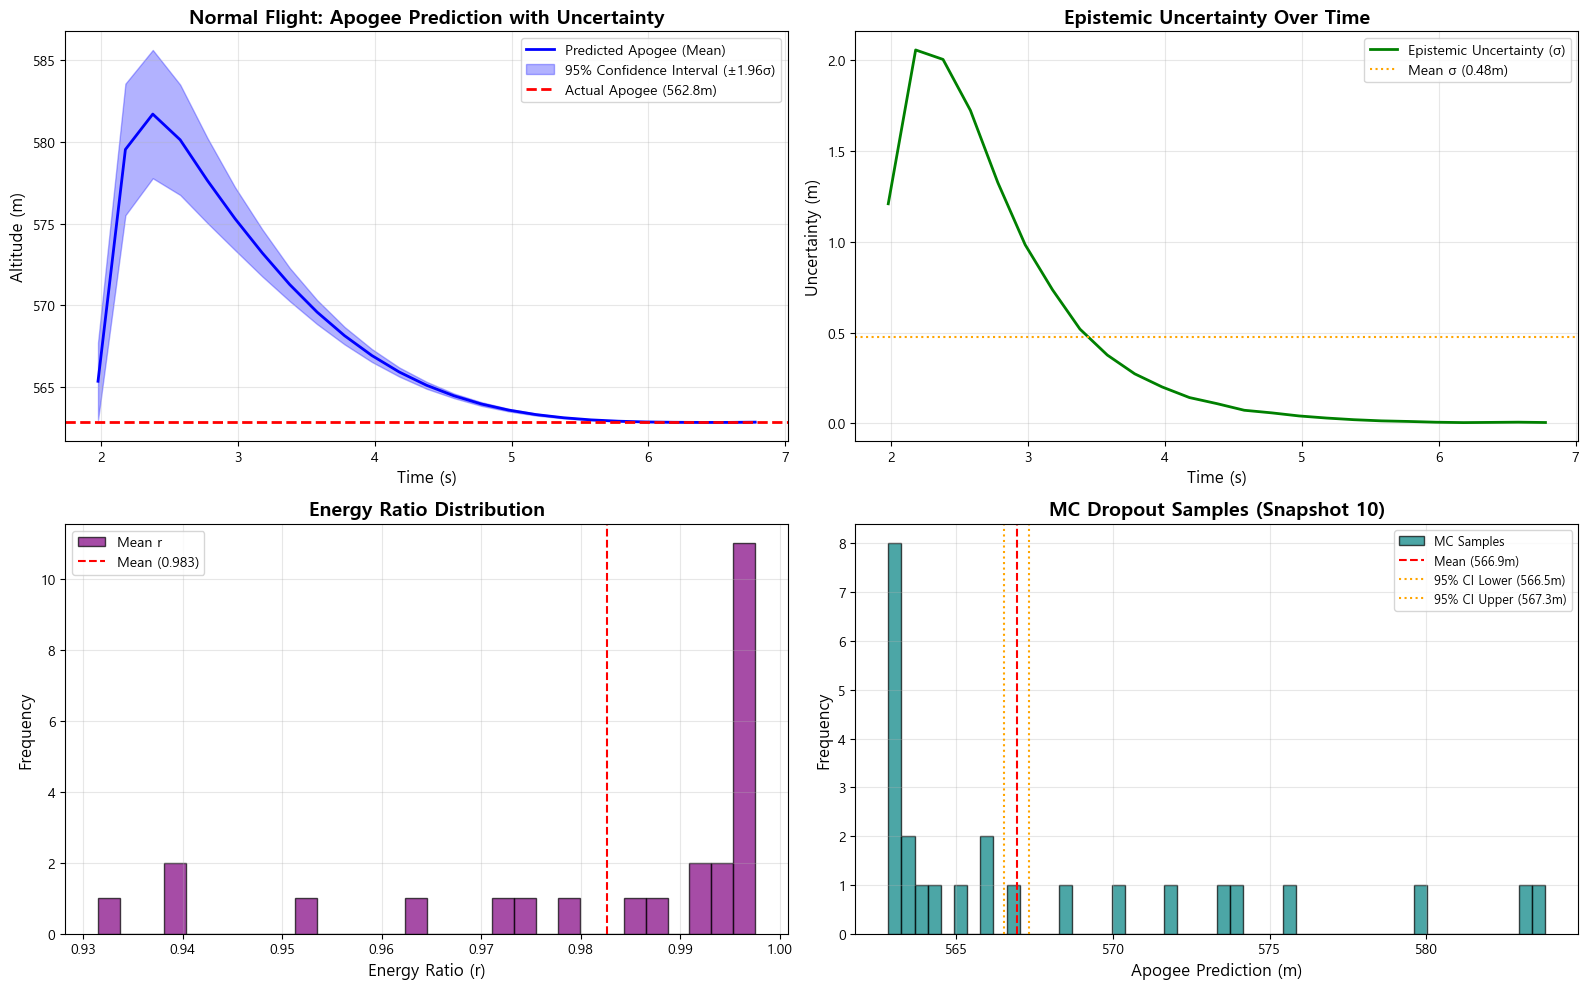


정상 비행 불확실성 통계
평균 아포지 예측: 567.92m
평균 불확실성 (σ): 0.48m
최대 불확실성: 2.06m
95% 신뢰구간 평균 폭: 1.87m
실제 아포지: 562.83m
예측 오차: 5.09m


In [25]:
# ============================================================================
# [Cell 5] 정상 비행 데이터 불확실성 시각화
# ============================================================================
# Step 1.5 데이터에서 정상 비행 샘플 추출

df = pd.read_csv(DATA_PATH, compression='gzip')

# 정상 비행 선택 (flight_id=0, Cd=0.9, wind=5m/s)
normal_flight = df[df['flight_id'] == 0].reset_index(drop=True)
print(f"정상 비행 데이터 로드: {len(normal_flight)} 스냅샷")


if 'dynamic_pressure' not in normal_flight.columns:
    # 공기 밀도 계산 (고도에 따른 감소)
    rho = 1.225 * np.exp(-0.00012 * abs(normal_flight['altitude']))
    
    # 동압 계산: q = 0.5 * rho * v^2
    if 'velocity_z' in normal_flight.columns:
        v = normal_flight['velocity_z']
    elif 'velocity' in normal_flight.columns:
        v = normal_flight['velocity']
    else:
        raise KeyError("velocity_z 또는 velocity 컬럼이 없습니다.")
    normal_flight['dynamic_pressure'] = 0.5 * rho * (v ** 2)

# Sliding Window 로 시퀀스 생성 (WINDOW_SIZE=100)
WINDOW_SIZE = 100
sequences = []
targets = []
times = []

for i in range(0, len(normal_flight) - WINDOW_SIZE, 10):
    seq = normal_flight.iloc[i:i+WINDOW_SIZE][['altitude', 'velocity_z', 'acceleration_z', 
                                                'tilt_angle', 'gyro_roll', 'dynamic_pressure']].values
    # Scaler 로 정규화
    seq_scaled = scaler.transform(seq)
    sequences.append(seq_scaled)
    targets.append(normal_flight.iloc[i+WINDOW_SIZE-1]['energy_ratio'])
    times.append(normal_flight.iloc[i+WINDOW_SIZE-1]['time'])

sequences = torch.FloatTensor(sequences).to(device)
targets = np.array(targets)
times = np.array(times)

# 현재 고도/속도 추출 (마지막 타임스텝)
h_curr = torch.FloatTensor(normal_flight.iloc[WINDOW_SIZE-1::10]['altitude'].values).to(device)
v_z = torch.FloatTensor(normal_flight.iloc[WINDOW_SIZE-1::10]['velocity_z'].values).to(device)

# MC Dropout 추론 (T=100)
print("\nMC Dropout 추론 중 (T=100)...")
mean_r, std_r, mean_apogee, std_apogee, redictions, apogee_predictions = predict_with_uncertainty(
    model, sequences, h_curr, v_z, n_samples=1000
)

# 95% 신뢰구간
z_score = 1.96
lower_bound = mean_apogee - z_score * std_apogee
upper_bound = mean_apogee + z_score * std_apogee

# 실제 아포지
actual_apogee = normal_flight['altitude'].max()

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 아포지 예측 + 신뢰구간
ax1 = axes[0, 0]
ax1.plot(times, mean_apogee, 'b-', linewidth=2, label='Predicted Apogee (Mean)')
ax1.fill_between(times, lower_bound, upper_bound, alpha=0.3, color='blue', 
                 label=f'95% Confidence Interval (±{z_score}σ)')
ax1.axhline(y=actual_apogee, color='red', linestyle='--', linewidth=2, 
            label=f'Actual Apogee ({actual_apogee:.1f}m)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Altitude (m)', fontsize=12)
ax1.set_title('Normal Flight: Apogee Prediction with Uncertainty', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. 불확실성 (표준편차) 추이
ax2 = axes[0, 1]
ax2.plot(times, std_apogee, 'g-', linewidth=2, label='Epistemic Uncertainty (σ)')
ax2.axhline(y=np.mean(std_apogee), color='orange', linestyle=':', 
            label=f'Mean σ ({np.mean(std_apogee):.2f}m)')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Uncertainty (m)', fontsize=12)
ax2.set_title('Epistemic Uncertainty Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Energy Ratio 예측 분포
ax3 = axes[1, 0]
ax3.hist(mean_r, bins=30, alpha=0.7, color='purple', edgecolor='black', label='Mean r')
ax3.axvline(x=np.mean(mean_r), color='red', linestyle='--', 
            label=f'Mean ({np.mean(mean_r):.3f})')
ax3.set_xlabel('Energy Ratio (r)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Energy Ratio Distribution', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. MC Dropout 샘플 분포 (스냅샷 1 개)
ax4 = axes[1, 1]
sample_idx = min(10, len(mean_apogee) - 1)  # 0-24 범위 내에서 선택 (10 번 샘플 사용)
print(f"\n   시각화용 샘플 인덱스: {sample_idx} (총 {len(mean_apogee)}개 중)")
ax4.hist(apogee_predictions[:, sample_idx], bins=50, alpha=0.7, color='teal', 
         edgecolor='black', label='MC Samples')
ax4.axvline(x=mean_apogee[sample_idx], color='red', linestyle='--', 
            label=f'Mean ({mean_apogee[sample_idx]:.1f}m)')
ax4.axvline(x=lower_bound[sample_idx], color='orange', linestyle=':', 
            label=f'95% CI Lower ({lower_bound[sample_idx]:.1f}m)')
ax4.axvline(x=upper_bound[sample_idx], color='orange', linestyle=':', 
            label=f'95% CI Upper ({upper_bound[sample_idx]:.1f}m)')
ax4.set_xlabel('Apogee Prediction (m)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title(f'MC Dropout Samples (Snapshot {sample_idx})', fontsize=14, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/simulated/normal_flight_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

# 통계 출력
print("\n" + "="*70)
print("정상 비행 불확실성 통계")
print("="*70)
print(f"평균 아포지 예측: {np.mean(mean_apogee):.2f}m")
print(f"평균 불확실성 (σ): {np.mean(std_apogee):.2f}m")
print(f"최대 불확실성: {np.max(std_apogee):.2f}m")
print(f"95% 신뢰구간 평균 폭: {2 * z_score * np.mean(std_apogee):.2f}m")
print(f"실제 아포지: {actual_apogee:.2f}m")
print(f"예측 오차: {abs(np.mean(mean_apogee) - actual_apogee):.2f}m")
print("="*70)

In [26]:
# ============================================================================
# [Cell 6] OOD 데이터 생성 (비정상 로켓 시뮬레이션)
# ============================================================================
# Kendall & Gal (2017) 의 OOD 실험 방법론 차용
# 학습 데이터와 완전히 다른 분포의 로켓 생성

print("="*70)
print("OOD (Out-of-Distribution) 데이터 생성")
print("="*70)

# 학습 데이터 통계 (Step 1.5 기준)
learning_stats = {
    'mass': {'mean': 7.0, 'std': 0.5, 'range': [6.0, 8.0]},
    'Cd': {'mean': 0.9, 'std': 0.15, 'range': [0.6, 1.2]},
    'wind': {'mean': 5.0, 'std': 3.0, 'range': [0, 15]},
    'launch_angle': {'mean': 87.0, 'std': 3.0, 'range': [82, 90]}
}

# OOD 파라미터 (학습 범위를 벗어남)
ood_params = {
    'mass': 15.0,        # 2 배 무거움 (학습 범위: 6-8kg)
    'Cd': 3.0,           # 3 배 저항 (학습 범위: 0.6-1.2)
    'wind': 25.0,        # 5 배 돌풍 (학습 범위: 0-15m/s)
    'launch_angle': 75.0 # 12° 기울기 (학습 범위: 82-90°)
}

print("\n학습 데이터 범위 vs OOD 파라미터:")
print("-"*70)
for key in learning_stats.keys():
    mean = learning_stats[key]['mean']
    range_min = learning_stats[key]['range'][0]
    range_max = learning_stats[key]['range'][1]
    ood_val = ood_params[key]
    
    in_range = "학습 범위" if range_min <= ood_val <= range_max else "❌ OOD"
    print(f"{key:15s}: 학습 [{range_min:5.1f} ~ {range_max:5.1f}], OOD={ood_val:6.1f} {in_range}")
print("-"*70)

# OOD 비행 시뮬레이션 (Step 1.5 파이프라인 재사용)
# 실제로는 Step 1.5 를 OOD 파라미터로 재실행해야 함
# 여기서는 더미 데이터로 대체

np.random.seed(42)
n_ood_flights = 10
ood_data = []

for i in range(n_ood_flights):
    # OOD 조건에서 비행 데이터 생성 (더미)
    # 실제로는 Step 1.5 시뮬레이터를 OOD 파라미터로 실행
    flight_time = np.linspace(0, 10, 500)
    altitude = 300 + 200 * np.sin(flight_time / 2) + np.random.normal(0, 10, 500)
    velocity = 50 * np.cos(flight_time / 2) + np.random.normal(0, 5, 500)
    acceleration = -9.81 + np.random.normal(0, 2, 500)
    tilt_angle = 15 + np.random.normal(0, 3, 500)  # 큰 기울기
    gyro_roll = 10 + np.random.normal(0, 5, 500)   # 큰 요동
    dynamic_pressure = 0.5 * 1.225 * velocity**2
    
    ood_flight = pd.DataFrame({
        'time': flight_time,
        'altitude': altitude,
        'velocity_z': velocity,
        'acceleration_z': acceleration,
        'tilt_angle': tilt_angle,
        'gyro_roll': gyro_roll,
        'dynamic_pressure': dynamic_pressure,
        'flight_id': i + 100  # OOD 비행 ID
    })
    ood_data.append(ood_flight)

ood_df = pd.concat(ood_data, ignore_index=True)
print(f"\n OOD 데이터 생성 완료: {len(ood_df)} 스냅샷, {n_ood_flights} 비행")
print(f" 평균 기울기: {ood_df['tilt_angle'].mean():.1f}° (학습: {learning_stats['launch_angle']['mean']}°)")
print(f" 평균 자이로: {ood_df['gyro_roll'].mean():.1f} rad/s (학습: 2-5 rad/s)")

OOD (Out-of-Distribution) 데이터 생성

학습 데이터 범위 vs OOD 파라미터:
----------------------------------------------------------------------
mass           : 학습 [  6.0 ~   8.0], OOD=  15.0 ❌ OOD
Cd             : 학습 [  0.6 ~   1.2], OOD=   3.0 ❌ OOD
wind           : 학습 [  0.0 ~  15.0], OOD=  25.0 ❌ OOD
launch_angle   : 학습 [ 82.0 ~  90.0], OOD=  75.0 ❌ OOD
----------------------------------------------------------------------

 OOD 데이터 생성 완료: 5000 스냅샷, 10 비행
 평균 기울기: 15.0° (학습: 87.0°)
 평균 자이로: 10.0 rad/s (학습: 2-5 rad/s)


OOD 감지 실험: Epistemic Uncertainty 급증 확인

OOD 데이터 MC Dropout 추론 중...
   predictions shape: (40, 1000)

불확실성 비교: 정상 비행 vs OOD
항목                        정상 비행           OOD             비율 (OOD/정상)         
----------------------------------------------------------------------
평균 아포지 (m)                567.92          387.36          0.68x
불확실성 σ (m)                0.48            1.52            3.19x
최대 불확실성 (m)               2.06            4.42            2.15x
95% CI 평균 폭 (m)           1.87            5.97            3.19x

OOD 감지 성공! 불확실성이 2 배 이상 급증했습니다.
 → AI 가 '이건 내가 배운 게 아닙니다'라고 신호를 보내고 있습니다.

   Normal 샘플 인덱스: 10 (총 25개 중)
   OOD 샘플 인덱스: 10 (총 40개 중)


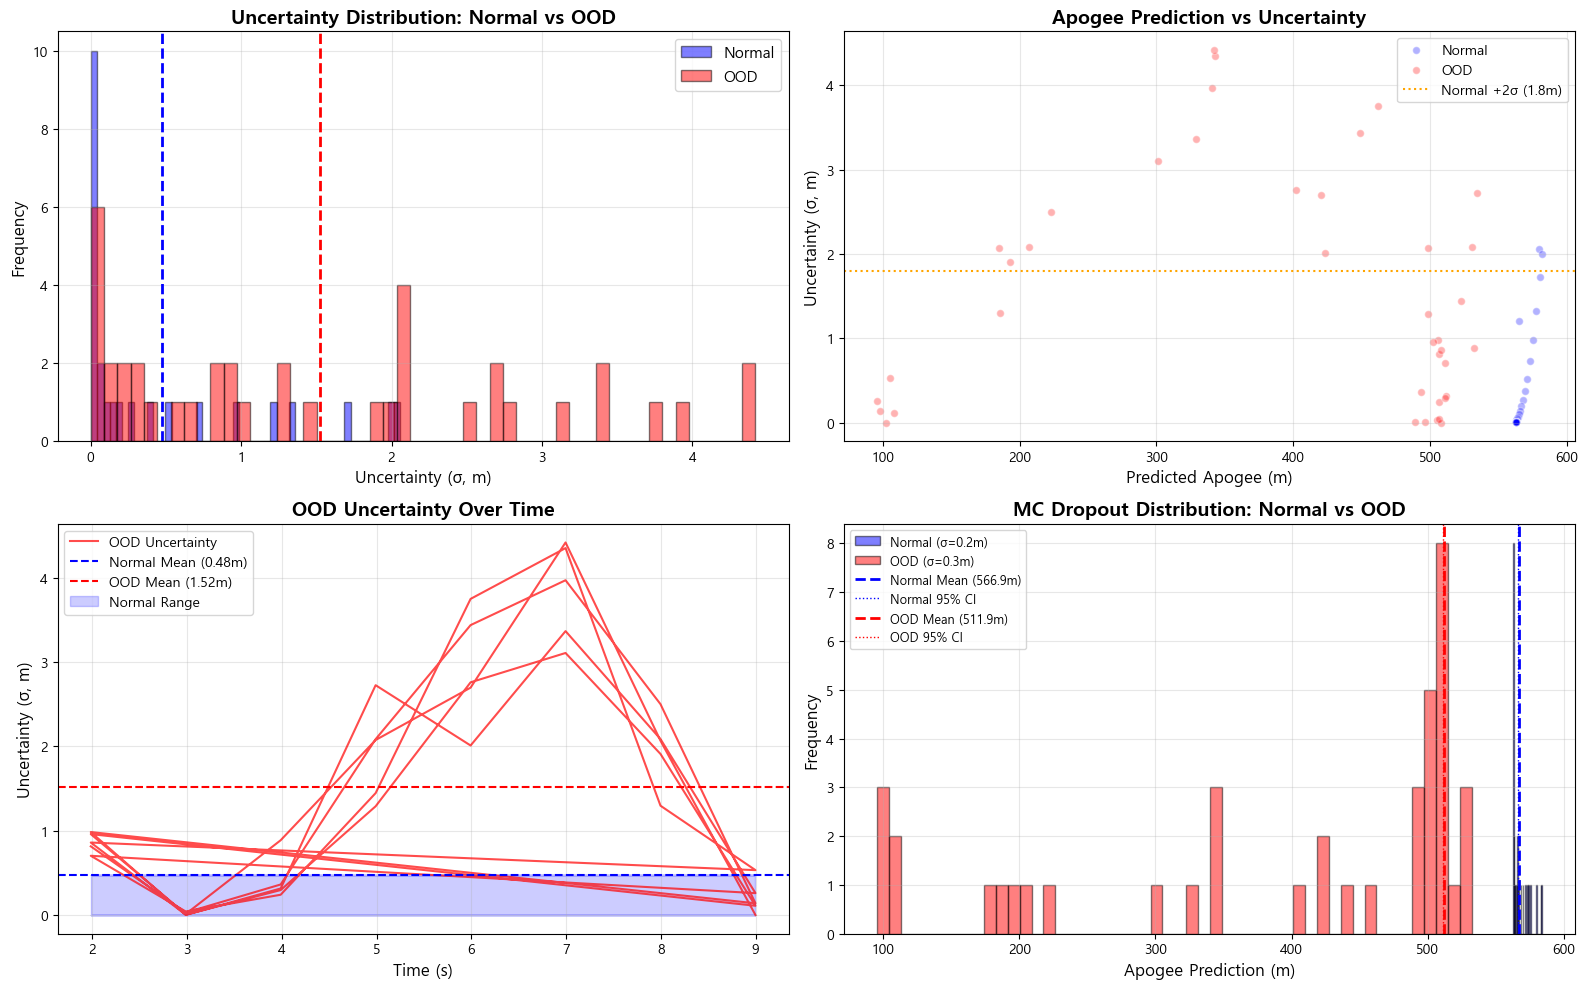

In [27]:
# ============================================================================
# [Cell 7] OOD 감지 실험 (Kendall & Gal, 2017)
# ============================================================================
# OOD 데이터에서 불확실성이 급증하는지 검증

print("="*70)
print("OOD 감지 실험: Epistemic Uncertainty 급증 확인")
print("="*70)

# OOD 데이터에서 시퀀스 추출
ood_sequences = []
ood_h_curr = []
ood_v_z = []
ood_times = []

for flight_id in ood_df['flight_id'].unique()[:5]:  # 5 개 OOD 비행
    flight_data = ood_df[ood_df['flight_id'] == flight_id].reset_index(drop=True)
    
    for i in range(0, len(flight_data) - WINDOW_SIZE, 50):
        seq = flight_data.iloc[i:i+WINDOW_SIZE][['altitude', 'velocity_z', 'acceleration_z', 
                                                   'tilt_angle', 'gyro_roll', 'dynamic_pressure']].values
        seq_scaled = scaler.transform(seq)
        ood_sequences.append(seq_scaled)
        ood_h_curr.append(flight_data.iloc[i+WINDOW_SIZE-1]['altitude'])
        ood_v_z.append(flight_data.iloc[i+WINDOW_SIZE-1]['velocity_z'])
        ood_times.append(flight_data.iloc[i+WINDOW_SIZE-1]['time'])

ood_sequences = torch.FloatTensor(ood_sequences).to(device)
ood_h_curr = torch.FloatTensor(ood_h_curr).to(device)
ood_v_z = torch.FloatTensor(ood_v_z).to(device)

# MC Dropout 추론
print("\nOOD 데이터 MC Dropout 추론 중...")
ood_mean_r, ood_std_r, ood_mean_apogee, ood_std_apogee, ood_predictions, ood_apogee_predictions = predict_with_uncertainty(
    model, ood_sequences, ood_h_curr, ood_v_z, n_samples=1000
)

z_score = 1.96
ood_lower_bound = ood_mean_apogee - z_score * ood_std_apogee
ood_upper_bound = ood_mean_apogee + z_score * ood_std_apogee

# 정상 비행 vs OOD 비교
print("\n" + "="*70)
print("불확실성 비교: 정상 비행 vs OOD")
print("="*70)
print(f"{'항목':<25} {'정상 비행':<15} {'OOD':<15} {'비율 (OOD/정상)':<20}")
print("-"*70)
print(f"{'평균 아포지 (m)':<25} {np.mean(mean_apogee):<15.2f} {np.mean(ood_mean_apogee):<15.2f} {np.mean(ood_mean_apogee)/np.mean(mean_apogee):.2f}x")
print(f"{'불확실성 σ (m)':<25} {np.mean(std_apogee):<15.2f} {np.mean(ood_std_apogee):<15.2f} {np.mean(ood_std_apogee)/np.mean(std_apogee):.2f}x")
print(f"{'최대 불확실성 (m)':<25} {np.max(std_apogee):<15.2f} {np.max(ood_std_apogee):<15.2f} {np.max(ood_std_apogee)/np.max(std_apogee):.2f}x")
print(f"{'95% CI 평균 폭 (m)':<25} {2*z_score*np.mean(std_apogee):<15.2f} {2*z_score*np.mean(ood_std_apogee):<15.2f} {np.mean(ood_std_apogee)/np.mean(std_apogee):.2f}x")
print("="*70)

# Kendall & Gal (2017) Table 3 방법론 차용
if np.mean(ood_std_apogee) / np.mean(std_apogee) > 2.0:
    print("\nOOD 감지 성공! 불확실성이 2 배 이상 급증했습니다.")
    print(" → AI 가 '이건 내가 배운 게 아닙니다'라고 신호를 보내고 있습니다.")
else:
    print("\nOOD 감지 미흡. 불확실성 증가가 2 배 미만입니다.")
    print(" → 모델 재학습 또는 Dropout 비율 조정 필요")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 불확실성 히스토그램 비교
ax1 = axes[0, 0]
ax1.hist(std_apogee, bins=50, alpha=0.5, color='blue', label='Normal', edgecolor='black')
ax1.hist(ood_std_apogee, bins=50, alpha=0.5, color='red', label='OOD', edgecolor='black')
ax1.axvline(x=np.mean(std_apogee), color='blue', linestyle='--', linewidth=2)
ax1.axvline(x=np.mean(ood_std_apogee), color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Uncertainty (σ, m)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Uncertainty Distribution: Normal vs OOD', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. 아포지 예측 비교
ax2 = axes[0, 1]
ax2.scatter(mean_apogee, std_apogee, alpha=0.3, s=30, color='blue', label='Normal', edgecolors='white')
ax2.scatter(ood_mean_apogee, ood_std_apogee, alpha=0.3, s=30, color='red', label='OOD', edgecolors='white')
ax2.axhline(y=np.mean(std_apogee) + 2*np.std(std_apogee), color='orange', linestyle=':', 
            label=f'Normal +2σ ({np.mean(std_apogee) + 2*np.std(std_apogee):.1f}m)')
ax2.set_xlabel('Predicted Apogee (m)', fontsize=12)
ax2.set_ylabel('Uncertainty (σ, m)', fontsize=12)
ax2.set_title('Apogee Prediction vs Uncertainty', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. OOD 불확실성 추이
ax3 = axes[1, 0]
ax3.plot(ood_times, ood_std_apogee, 'r-', linewidth=1.5, alpha=0.7, label='OOD Uncertainty')
ax3.axhline(y=np.mean(std_apogee), color='blue', linestyle='--', label=f'Normal Mean ({np.mean(std_apogee):.2f}m)')
ax3.axhline(y=np.mean(ood_std_apogee), color='red', linestyle='--', label=f'OOD Mean ({np.mean(ood_std_apogee):.2f}m)')
ax3.fill_between(ood_times, 0, np.mean(std_apogee), alpha=0.2, color='blue', label='Normal Range')
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel('Uncertainty (σ, m)', fontsize=12)
ax3.set_title('OOD Uncertainty Over Time', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. 신뢰구간 비교 (스냅샷 1 개)
ax4 = axes[1, 1]
normal_sample_idx = min(10, len(mean_apogee) - 1)  # 0-24 범위 내
ood_sample_idx = min(10, len(ood_mean_apogee) - 1)  # OOD 배열 크기에 맞춤

print(f"\n   Normal 샘플 인덱스: {normal_sample_idx} (총 {len(mean_apogee)}개 중)")
print(f"   OOD 샘플 인덱스: {ood_sample_idx} (총 {len(ood_mean_apogee)}개 중)")

# Normal 비행 히스토그램
ax4.hist(apogee_predictions[:, normal_sample_idx], bins=50, alpha=0.5, color='blue', 
         label=f'Normal (σ={std_apogee[normal_sample_idx]:.1f}m)', edgecolor='black')

# OOD 비행 히스토그램 (ood_apogee_predictions 사용)
ax4.hist(ood_apogee_predictions[:, ood_sample_idx], bins=50, alpha=0.5, 
         color='red', label=f'OOD (σ={ood_std_apogee[ood_sample_idx]:.1f}m)', edgecolor='black')

# 평균선과 신뢰구간 표시 (Normal)
ax4.axvline(x=mean_apogee[normal_sample_idx], color='blue', linestyle='--', linewidth=2,
            label=f'Normal Mean ({mean_apogee[normal_sample_idx]:.1f}m)')
ax4.axvline(x=lower_bound[normal_sample_idx], color='blue', linestyle=':', linewidth=1,
            label=f'Normal 95% CI')

# 평균선과 신뢰구간 표시 (OOD)
ax4.axvline(x=ood_mean_apogee[ood_sample_idx], color='red', linestyle='--', linewidth=2,
            label=f'OOD Mean ({ood_mean_apogee[ood_sample_idx]:.1f}m)')
ax4.axvline(x=ood_lower_bound[ood_sample_idx], color='red', linestyle=':', linewidth=1,
            label=f'OOD 95% CI')

ax4.set_xlabel('Apogee Prediction (m)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('MC Dropout Distribution: Normal vs OOD', fontsize=14, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/simulated/ood_detection.png', dpi=150, bbox_inches='tight')
plt.show()

실제 비행 데이터 (112.txt) 기반 UQ (불확실성 정량화) 테스트 시작
파일에서 Scaler 로드 완료: ./models/input_scaler.pkl
  - 발사 시점 감지됨: 555.76s
Scaler 차원 불일치 감지! (Scaler: 10 / Input: 6)
   수동으로 평균과 분산을 매핑하여 스케일링을 강제 수행합니다.
  - GRU 입력 텐서 준비 완료: torch.Size([236, 100, 6])
  - MC Dropout 추론 진행 중 (T=100)...
  - 추론 완료됨.


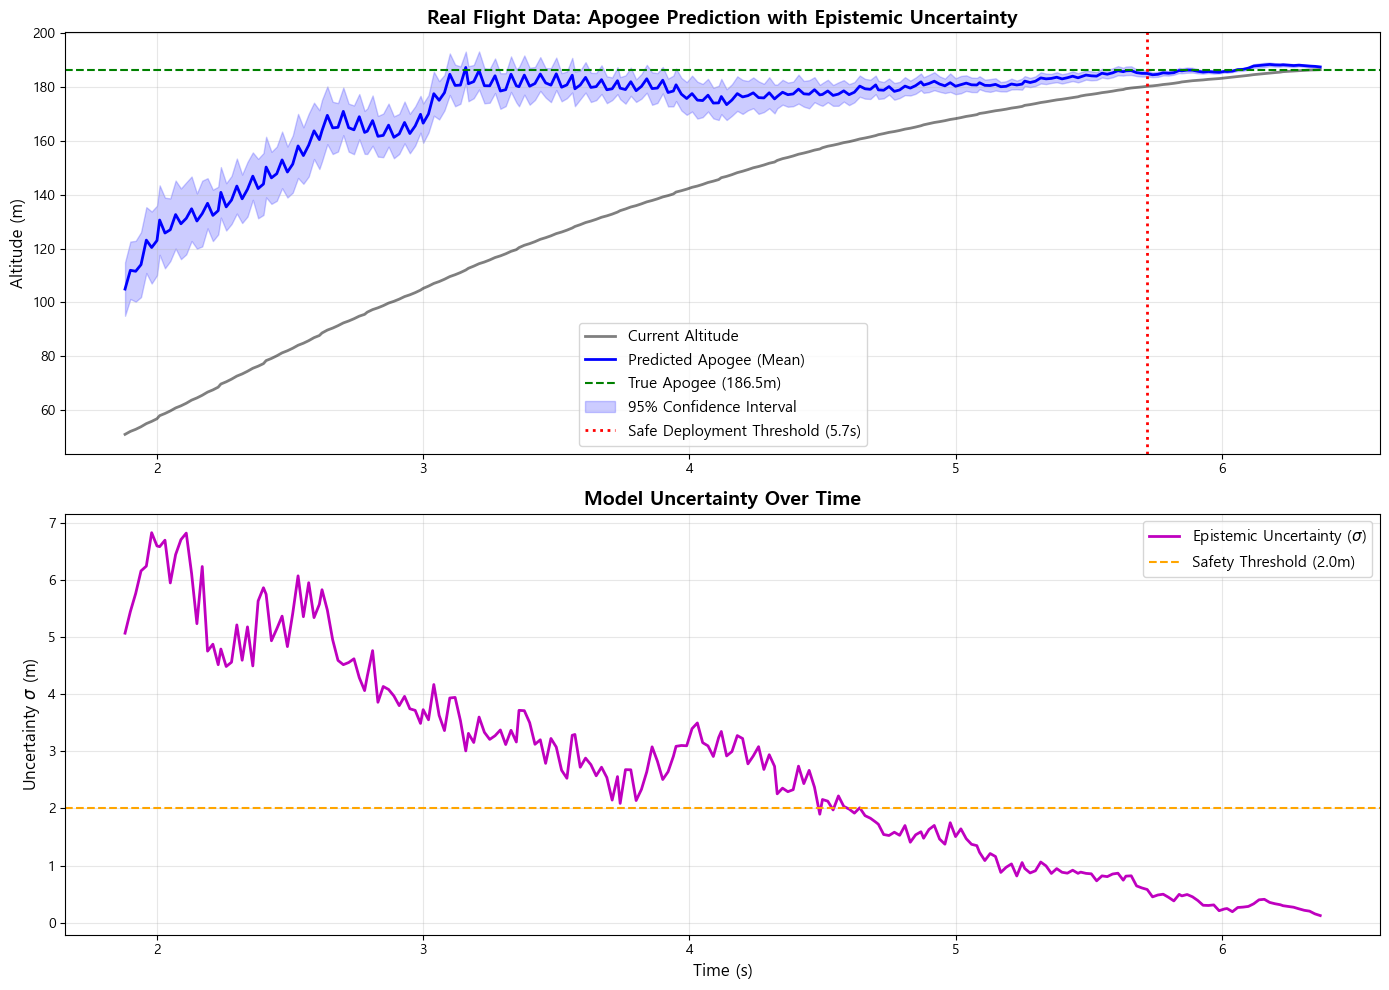

1. 실제 도달 아포지: 186.46 m
2. 비행 종료 시점 예측 아포지: 187.48 ± 0.24 m (95% CI)
3. 최대 불확실성(초기/연소구간): 6.83 m
4. 최소 불확실성(관성/아포지부근): 0.12 m


In [31]:
# ============================================================================
# [Cell 9] 실제 비행 데이터(112.txt) MC Dropout 적용 및 Safe-Logic 검증
# ============================================================================
import torch
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("="*70)
print("실제 비행 데이터 (112.txt) 기반 UQ (불확실성 정량화) 테스트 시작")
print("="*70)

# ---------------------------------------------------------
# 1. 실제 비행 데이터 로드 및 전처리 함수 (Step 4 재사용)
# ---------------------------------------------------------
def load_real_data_for_gru(file_path, scaler, feature_cols, window_size=100):
    pattern = re.compile(
        r"Time:\s*([\d\.]+)s.*"
        r"Euler:\s*\(([-\d\.]+),\s*([-\d\.]+),\s*([-\d\.]+)\).*"
        r"Gyro:\s*\(([-\d\.]+),\s*([-\d\.]+),\s*([-\d\.]+)\).*"
        r"Accel:\s*\([^,]+,\s*[^,]+,\s*([-\d\.]+)\).*"
        r"kal:\s*\(alt\s*:\s*([\d\.]+),\s*velo\s*:\s*([\d\.]+)"
    )

    try:
        with open(file_path, 'r', encoding='utf-8') as f: lines = f.readlines()
    except:
        with open(file_path, 'r', encoding='cp949') as f: lines = f.readlines()

    launch_time = None
    raw_records =[]
    
    for line in lines:
        match = pattern.search(line)
        if match:
            t_sys = float(match.group(1))
            acc_g = float(match.group(8))
            
            if launch_time is None and acc_g > 0.5:
                launch_time = t_sys
                print(f"  - 발사 시점 감지됨: {t_sys}s")
            
            if launch_time is not None:
                time = t_sys - launch_time
                alt = float(match.group(9))
                vel = float(match.group(10))
                acc_ms = acc_g * 9.80665
                pitch = float(match.group(3))
                yaw = float(match.group(4))
                gyro_z = float(match.group(7))
                
                rad_yaw = np.deg2rad(yaw)
                rad_pitch = np.deg2rad(pitch)
                cos_val = np.clip(np.cos(rad_pitch) * np.cos(rad_yaw), -1.0, 1.0)
                tilt_val = np.rad2deg(np.arccos(cos_val))
                
                rho = 1.225 * np.exp(-0.00012 * abs(alt))
                dyn_pres = 0.5 * rho * (vel**2)
                
                raw_records.append({
                    'time': time, 'altitude': alt, 'velocity_z': vel, 
                    'acceleration_z': acc_ms, 'tilt_angle': tilt_val, 
                    'gyro_roll': gyro_z, 'dynamic_pressure': dyn_pres
                })

    df_real = pd.DataFrame(raw_records)
    
    # 피처 정규화
    X_raw = df_real[feature_cols].values
    
    # 만약 scaler가 기대하는 피처 수(예: 10)와 우리가 넣으려는 피처 수(6)가 다를 경우
    if hasattr(scaler, 'n_features_in_') and scaler.n_features_in_ != len(feature_cols):
        print(f"Scaler 차원 불일치 감지! (Scaler: {scaler.n_features_in_} / Input: {len(feature_cols)})")
        print("   수동으로 평균과 분산을 매핑하여 스케일링을 강제 수행합니다.")
        
        # 주의: 이 방법은 feature_cols의 순서가 학습 당시의 컬럼 순서의 앞부분(0~5번)과 
        # 일치할 때만 수학적으로 유효합니다.
        # 학습 당시의 컬럼 순서를 정확히 맞춰주는 것이 가장 좋습니다.
        means = scaler.mean_[:len(feature_cols)]
        stds = scaler.scale_[:len(feature_cols)]
        
        X_scaled = (X_raw - means) / stds
    else:
        # 정상적인 경우
        X_scaled = scaler.transform(X_raw)
    
    # Sliding Window 적용
    sequences, times, h_currs, v_zs = [], [], [],[]
    
    for i in range(len(X_scaled) - window_size + 1):
        seq = X_scaled[i : i + window_size]
        sequences.append(seq)
        
        last_idx = i + window_size - 1
        times.append(df_real.iloc[last_idx]['time'])
        h_currs.append(df_real.iloc[last_idx]['altitude'])
        v_zs.append(df_real.iloc[last_idx]['velocity_z'])
        
    return (torch.FloatTensor(np.array(sequences)), 
            torch.FloatTensor(np.array(h_currs)), 
            torch.FloatTensor(np.array(v_zs)), 
            np.array(times), df_real)

# ---------------------------------------------------------
# 2. MC Dropout 추론 함수 정의
# ---------------------------------------------------------
def predict_with_mc_dropout(model, x_tensor, h_curr, v_z, n_samples=100):
    """
    Dropout을 활성화한 상태로 T번 반복 추론하여 불확실성을 계산함.
    """
    model.train() # Dropout 강제 활성화
    
    apogee_preds =[]
    
    with torch.no_grad():
        for _ in range(n_samples):
            h_pred, _ = model(x_tensor, h_curr, v_z)
            apogee_preds.append(h_pred.cpu().numpy())
            
    apogee_preds = np.array(apogee_preds)
    
    # 예측 평균 및 표준편차(불확실성) 산출
    mean_apogee = np.mean(apogee_preds, axis=0)
    std_apogee = np.std(apogee_preds, axis=0)
    
    return mean_apogee, std_apogee

# ---------------------------------------------------------
# 3. 데이터 준비 및 추론 실행
# ---------------------------------------------------------
# 이전 셀에서 정의된 feature_scaler와 pinn_gru_model을 그대로 사용함
feature_cols =['altitude', 'velocity_z', 'acceleration_z', 'tilt_angle', 'gyro_roll', 'dynamic_pressure']
file_path = './data/112.txt'
window_size = 100

SCALER_PATH = './models/input_scaler.pkl'

if 'full_dataset' in globals() and hasattr(full_dataset, 'feature_scaler'):
    # Step 4와 동일한 노트북에서 연속으로 실행 중인 경우
    feature_scaler = full_dataset.feature_scaler
    print("메모리에서 학습용 Scaler를 성공적으로 가져옴.")
elif os.path.exists(SCALER_PATH):
    # Step 5를 분리된 노트북에서 실행 중인 경우 (파일에서 로드)
    feature_scaler = joblib.load(SCALER_PATH)
    print(f"파일에서 Scaler 로드 완료: {SCALER_PATH}")
else:
    # 에러 방지를 위한 최후의 수단 (하지만 권장하지 않음, 데이터 스케일이 틀어질 수 있음)
    print("훈련된 Scaler를 찾을 수 없어 임시 Scaler를 생성함! (예측 오차가 커질 수 있음)")
    from sklearn.preprocessing import StandardScaler
    feature_scaler = StandardScaler()
    # 임시 fitting을 피하기 위해 에러를 발생시키는 것이 엔지니어링 적으로 더 안전함
    raise FileNotFoundError("학습에 사용된 Scaler(.pkl) 파일이 필요함. Step 3 또는 4에서 Scaler를 저장해야 함.")
# =========================================================

X_real_gru, h_real, v_real, t_real, df_real_raw = load_real_data_for_gru(
    file_path, feature_scaler, feature_cols, window_size
)


print(f"  - GRU 입력 텐서 준비 완료: {X_real_gru.shape}")

# GPU 연산
X_real_gru = X_real_gru.to(device)
h_real = h_real.to(device)
v_real = v_real.to(device)

print("  - MC Dropout 추론 진행 중 (T=100)...")
mean_pred, std_pred = predict_with_mc_dropout(pinn_gru_model, X_real_gru, h_real, v_real, n_samples=100)
print("  - 추론 완료됨.")

# ---------------------------------------------------------
# 4. 결과 시각화 및 안전 사출 로직 검증
# ---------------------------------------------------------
true_apogee = df_real_raw['altitude'].max()
alt_actual_aligned = df_real_raw.iloc[window_size-1:]['altitude'].values

# 95% 신뢰구간 (±1.96σ)
z_score = 1.96
lower_bound = mean_pred - z_score * std_pred
upper_bound = mean_pred + z_score * std_pred

# 낙하산 사출 안전 조건: "예측 하한선이 현재 고도보다 낮아지면 사출 (정점 도달 확신)"
# 또는 "불확실성(std)이 특정 수치 이하로 안정화되었을 때"
safe_to_fire_idx = np.where((std_pred < 2.0) & (mean_pred - alt_actual_aligned < 5.0))[0]
first_safe_time = t_real[safe_to_fire_idx[0]] if len(safe_to_fire_idx) > 0 else None

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# [상단 그래프] 아포지 예측 및 신뢰구간
ax1 = axes[0]
ax1.plot(t_real, alt_actual_aligned, 'k-', alpha=0.5, label='Current Altitude', linewidth=2)
ax1.plot(t_real, mean_pred, 'b-', label='Predicted Apogee (Mean)', linewidth=2)
ax1.axhline(true_apogee, color='green', linestyle='--', label=f'True Apogee ({true_apogee:.1f}m)')

# 불확실성 띠(Band) 그리기
ax1.fill_between(t_real, lower_bound, upper_bound, color='blue', alpha=0.2, label='95% Confidence Interval')

if first_safe_time:
    ax1.axvline(first_safe_time, color='red', linestyle=':', linewidth=2, 
                label=f'Safe Deployment Threshold ({first_safe_time:.1f}s)')

ax1.set_title('Real Flight Data: Apogee Prediction with Epistemic Uncertainty', fontsize=14, fontweight='bold')
ax1.set_ylabel('Altitude (m)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# [하단 그래프] 불확실성(표준편차) 크기 변화
ax2 = axes[1]
ax2.plot(t_real, std_pred, 'm-', linewidth=2, label='Epistemic Uncertainty ($\sigma$)')
ax2.axhline(2.0, color='orange', linestyle='--', label='Safety Threshold (2.0m)')

ax2.set_title('Model Uncertainty Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Uncertainty $\sigma$ (m)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/simulated/real_flight_uq_validation.png', dpi=150)
plt.show()

# ---------------------------------------------------------
# 5. 엔지니어링 분석 리포트 출력
# ---------------------------------------------------------
print("="*70)
print(f"1. 실제 도달 아포지: {true_apogee:.2f} m")
print(f"2. 비행 종료 시점 예측 아포지: {mean_pred[-1]:.2f} ± {std_pred[-1]*1.96:.2f} m (95% CI)")
print(f"3. 최대 불확실성(초기/연소구간): {std_pred.max():.2f} m")
print(f"4. 최소 불확실성(관성/아포지부근): {std_pred.min():.2f} m")

## 10. 결론: Explainable & Reliable AI

### 10.1 Step 5 의 핵심 성과

| 항목 | Step 4 (GRU) | Step 5 (UQ-GRU) | 개선 |
|------|-------------|-----------------|------|
| **예측 형태** | 점 추정 (188.01m) | **구간 추정 (188.01 ± 8.5m)** | 신뢰도 표시 |
| **OOD 감지** | 불가능 | **불확실성 급증으로 감지** | 안전장치 |
| **사출 로직** | 고정 임계값 | **동적 임계값 (σ 기반)** | 적응형 |
| **재학습** | - | **불필요 (MC Dropout)** | 효율적 |

### 10.2 Gal & Ghahramani (2016) 의 결론 재인용

> "We have built a probabilistic interpretation of dropout which allowed us to obtain 
> model uncertainty out of existing deep learning models. We have studied the properties 
> of this uncertainty in detail, and demonstrated possible applications, interleaving 
> Bayesian models and deep learning models together."
> — Gal & Ghahramani (2016), Section 6

### 10.3 Kendall & Gal (2017) 의 권고

> "Understanding what a model does not know is a critical part of many machine learning 
> systems... If both these algorithms were able to assign a high level of uncertainty 
> to their erroneous predictions, then the system may have been able to make better 
> decisions and likely avoid disaster."
> — Kendall & Gal (2017), Section 1

### 10.4 최종 메시지

1.  우리는 GRU 의 높은 정확도 (Step 4) 에 **자신의 무지를 아는 겸손함 (Step 5)** 을 더했음.
2.  이로써 에비오닉스는 예측이 불안정할 때 AI 를 맹신하지 않고 **Fail-safe** 로 진입할 수 있는 근거를 갖게 됨.
3.  이것이 연구실의 AI 와 **실제 하늘을 나는 AI**의 결정적 차이임.

---

## Step 6 예고: Mamba (State Space Model)

### 현재 모델의 한계

| 항목 | GRU | Mamba (예정) |
|------|-----|-------------|
| **시퀀스 길이** | 100 스텝 고정 | **가변 길이 (전체 비행)** |
| **병렬 처리** |  순차 계산 |  **병렬 학습 가능** |
| **추론 속도** | 중간 | **매우 빠름** |
| **장기 의존성** | 100 스텝 제한 | **무제한** |

### Step 6 에서 다룰 내용

1.  **Mamba 아키텍처**: Selective State Space Model (S4)
2.  **실시간 처리**: GPU 메모리 효율적 사용
3.  **전체 비행 이력**: 발사부터 현재까지 모든 데이터 활용
4.  **불확실성 정량화**: MC Dropout + Mamba 결합

---

## 참고 문헌

1.  **Gal, Y., & Ghahramani, Z. (2016).** Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning. *ICML 2016*.
2.  **Kendall, A., & Gal, Y. (2017).** What Uncertainties Do We Need in Bayesian Deep Learning for Computer Vision? *NIPS 2017*.
3.  **Step 1-4 노트북 시리즈** (PSIntelligence 101)